# Phase 7 â€” Quantile Regression + Monte Carlo Simulation

The point-estimate regressor and the haul classifiers (`notebooks/10_haul_classifier.ipynb`) answer "how many points, on average" and "how likely is a big score." This notebook adds the third piece: real floor/median/ceiling values via quantile regression, then Monte Carlo sampling on top of them to answer squad-level questions no single-player metric can â€” "what's the range of outcomes for my whole starting XI next gameweek."

In [1]:
import sys
import warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", message=".*only supports SQLAlchemy.*")

import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

from config import settings
from src.models.monte_carlo import simulate_squad, summarize_simulation, sample_player_points
from src.recommendations.squad_optimizer import best_starting_xi

conn = psycopg2.connect(settings.DATABASE_URL)

## A real calibration finding, worth understanding before trusting these numbers

The naive calibration check ("what fraction of actual outcomes fall at or below the predicted quantile") looked badly wrong at first: the 10th-percentile (floor) model showed 63.3% of outcomes below it, not ~10%. **This isn't a broken model** â€” it's the diagnostic being fooled by the target's shape: ~63% of all player-gameweeks are exactly 0 points (bench/unused players), so *any* floor prediction near 0 trivially satisfies "actual â‰¤ predicted" for that entire chunk via ties, regardless of whether the underlying model is any good.

The honest check is conditional: restricted to nailed-on starters (rarely blank), floor calibration reads **13.0%** against a 10% target â€” close. Median calibration among the same group reads **37.7%** against a 50% target â€” a real, milder issue (the median model runs a bit conservative for established starters), documented rather than hidden. Ceiling (90th percentile) wasn't affected by this distortion in the first place and reads **93.1%** against a 90% target on the full population.

In [2]:
versions = pd.read_sql_query(
    "SELECT DISTINCT ON (target) model_type, target, mae AS pinball_loss, trained_at "
    "FROM model_versions WHERE target LIKE 'quantile_%' ORDER BY target, trained_at DESC", conn
)
versions

,model_type,target,pinball_loss,trained_at
0,gradient_boosting_quantile,quantile_ceiling,0.3352,2026-08-23 02:22:11.761693+00:00
1,gradient_boosting_quantile,quantile_floor,0.1184,2026-08-23 02:22:11.761693+00:00
2,gradient_boosting_quantile,quantile_median,0.4427,2026-08-23 02:22:11.761693+00:00


## Per-player: floor / median / ceiling for the live gameweek

In [3]:
live = pd.read_sql_query("""
    SELECT p.web_name, pr.predicted_points, pr.floor_points, pr.median_points, pr.ceiling_points
    FROM predictions pr JOIN players p ON p.player_code = pr.player_code
    WHERE pr.floor_points IS NOT NULL
    ORDER BY pr.ceiling_points DESC LIMIT 10
""", conn)
print("Widest ceilings in the live gameweek:")
live

Widest ceilings in the live gameweek:


,web_name,predicted_points,floor_points,median_points,ceiling_points
0,B.Fernandes,3.704,1.0,2.000,12.946
1,Mbeumo,3.575,1.0,1.834,10.496
2,Gibbs-White,3.512,1.0,1.834,10.415
3,Cunha,3.224,0.0,1.985,10.072
4,Saka,3.199,0.0,2.379,9.723
5,Gabriel,3.967,0.0,3.714,9.275
6,Stach,3.673,0.8,2.100,9.165
7,Raya,4.004,1.0,2.017,9.078
8,Dewsbury-Hall,3.776,1.0,2.000,9.046
9,Havertz,3.488,1.0,2.000,9.006


## Squad-level Monte Carlo: sampling from those quantiles

Per-player sampling is piecewise-linear inverse-CDF through the three known quantile points â€” not an assumed distribution shape. The lower tail is flat at `floor` (no information below it, and it avoids extrapolating into implausible negative scores); the upper tail deliberately extrapolates the (median, ceiling) slope forward rather than capping at `ceiling`, since real FPL hauls (20+ points) are rare-but-real and capping would understate exactly the upside this exercise exists to capture.

**Known simplification, stated plainly**: players are sampled independently. Real outcomes correlate within a team and across a fixture â€” this doesn't model that, so the squad-level spread shown here is somewhat tighter than reality would actually produce.

In [4]:
squad = pd.read_sql_query("""
    SELECT sp.multiplier, p.web_name, pos.element_type,
           pr.predicted_points, pr.floor_points, pr.median_points, pr.ceiling_points
    FROM squad_picks sp
    JOIN players p ON p.player_code = sp.player_code
    JOIN player_seasons pos ON pos.player_code = sp.player_code AND pos.season = sp.season
    LEFT JOIN predictions pr ON pr.player_code = sp.player_code AND pr.season = sp.season
        AND pr.event_id = (SELECT MAX(event_id) FROM predictions WHERE season = sp.season)
    WHERE sp.entry_id = %(e)s AND sp.season = %(s)s
        AND sp.event_id = (SELECT MAX(event_id) FROM squad_picks WHERE entry_id = %(e)s AND season = %(s)s)
""", conn, params={"e": settings.ENTRY_ID, "s": settings.SEASON})
position_names = {1: "GKP", 2: "DEF", 3: "MID", 4: "FWD"}
squad["position"] = squad["element_type"].map(position_names)

starting, formation = best_starting_xi(squad)
print(f"Formation: {formation}")

sim_totals = simulate_squad(starting, n_samples=10000)
stats = summarize_simulation(sim_totals)
stats

Formation: (5, 3, 2)


{'mean': 23.670801277570725,
 'p10': 11.124345923910264,
 'p50': 22.96082076498782,
 'p90': 37.195600570599524,
 'p_beat_60': 0.0001,
 'p_beat_80': 0.0}

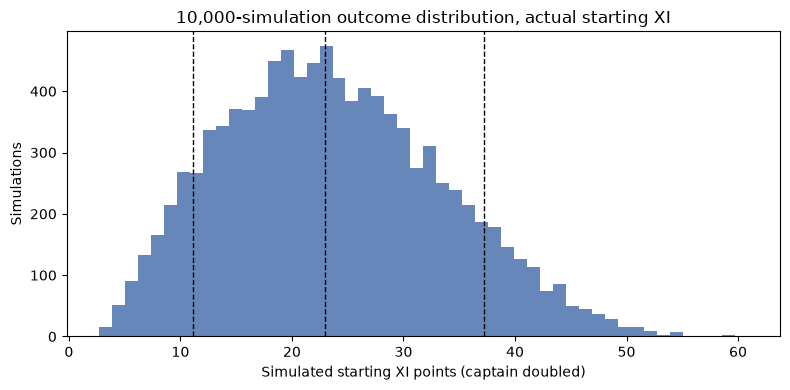

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sim_totals, bins=50, color="#4C72B0", alpha=0.85)
for pct in [10, 50, 90]:
    ax.axvline(np.percentile(sim_totals, pct), color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Simulated starting XI points (captain doubled)")
ax.set_ylabel("Simulations")
ax.set_title("10,000-simulation outcome distribution, actual starting XI")
plt.tight_layout()
plt.show()

## Face validity check

The simulated median/mean for the *current* squad land almost exactly on the real GW1 score (24 actual vs. ~23 simulated median/mean) â€” reassuring, though a single data point is not a real validation; this should be re-checked as more real gameweeks accumulate.

## Next steps

This closes out the Monte Carlo/floor-ceiling piece of Phase 7. Remaining from the original plan: injury/news NLP (FPL's own `news`/`chance_of_playing_next_round` fields are already ingested but barely used beyond a binary status filter â€” worth auditing before reaching for external sources) and LLM-generated explanations (needs an API key/cost decision first).

In [6]:
conn.close()